# Previsão de Decisões Judiciais — Pipeline com Transformers

Este notebook usa **representações de Transformers** (fine-tuning e embeddings contextuais) em vez de TF-IDF.

> Lage-Freitas et al. (2022). *Predicting Brazilian Court Decisions*. PeerJ Computer Science.

**Modelos treinados neste arquivo:**
- DistilBERT Português *(fine-tuning)*
- Legal-BERT PT-BR *(fine-tuning — treinado em documentos do STF)*
- Sentence-BERT Jurídico *(embeddings + classificador linear)*
- BERTimbau Base *(fine-tuning — replicação do modelo neural do artigo, para referência)*

**Por que o pré-processamento é diferente aqui:**
Transformers usam tokenização de subpalavras e atenção contextual — eles já capturam relações semânticas que stemming e remoção de stopwords destruiriam. Remover "não" de uma frase, por exemplo, pode inverter o significado de uma decisão. Por isso, o texto é mantido **praticamente intacto**, com apenas normalização leve.

## 0. Instalação de dependências

In [ ]:
!pip install datasets nltk scikit-learn pandas numpy seaborn matplotlib --quiet
!pip install transformers torch sentence-transformers accelerate --quiet

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import re
import time

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)
from sentence_transformers import SentenceTransformer
from datasets import load_dataset

import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('Aviso: GPU não disponível. Ative em Runtime > Change runtime type > T4 GPU.')

c:\Users\flavi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: cpu
Aviso: GPU não disponível. Ative em Runtime > Change runtime type > T4 GPU.


## 2. Carregamento dos dados
> Idêntico ao artigo original e ao notebook TF-IDF

In [3]:
# ── Carregamento do dataset — idêntico ao artigo original ───────────────────
print('Carregando dataset...')
raw = load_dataset('joelniklaus/brazilian_court_decisions', 'default')

df_train = raw['train'].to_pandas()
df_val   = raw['validation'].to_pandas()
df_test  = raw['test'].to_pandas()

data = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f'data.shape={data.shape}  full data set')

Carregando dataset...


data.shape=(4043, 10)  full data set


## 3. Limpeza dos dados
> Idêntica ao artigo original e ao notebook TF-IDF — garante que os dois notebooks partem exatamente da mesma base

In [4]:
# ── Limpeza idêntica ao artigo original (Lage-Freitas et al., 2022) ─────────

data = data.dropna(subset=['decision_description'])
data = data.dropna(subset=['judgment_label'])
print(f'data.shape={data.shape}  dropna')

data = data.drop_duplicates(subset=['process_number'])
print(f'data.shape={data.shape}  removed duplicated samples by process_number')

data = data.drop_duplicates(subset=['decision_description'])
print(f'data.shape={data.shape}  removed duplicated samples by decision_description')

data = data.query('judgment_label != "conflito-competencia"')
print(f'data.shape={data.shape}  removed conflito-competencia')
data = data.query('judgment_label != "prejudicada"')
print(f'data.shape={data.shape}  removed prejudicada')
data = data.query('judgment_label != "not-cognized"')
print(f'data.shape={data.shape}  removed not-cognized')

data_no      = data.query('judgment_label == "no"')
data_yes     = data.query('judgment_label == "yes"')
data_partial = data.query('judgment_label == "partial"')

data_merged = data_no.merge(data_yes, how='outer')
data = data_merged.merge(data_partial, how='outer')
print(f'data.shape={data.shape}  merged yes/no/partial')

indexNames = data[
    (data['decision_description'] == str(-1)) |
    (data['decision_description'] == str(-2)) |
    (data['judgment_label']       == str(-1)) |
    (data['judgment_label']       == str(-2))
].index
data.drop(indexNames, inplace=True)
print(f'data.shape={data.shape}  removed -1 and -2 values')

data = data.reset_index(drop=True)

print('\nDistribuição final dos rótulos:')
print(data['judgment_label'].value_counts())

data.shape=(4043, 10)  dropna
data.shape=(4043, 10)  removed duplicated samples by process_number
data.shape=(4043, 10)  removed duplicated samples by decision_description
data.shape=(4043, 10)  removed conflito-competencia
data.shape=(4043, 10)  removed prejudicada
data.shape=(4043, 10)  removed not-cognized
data.shape=(4043, 10)  merged yes/no/partial
data.shape=(4043, 10)  removed -1 and -2 values

Distribuição final dos rótulos:
judgment_label
no         2415
partial     866
yes         762
Name: count, dtype: int64


## 4. Pré-processamento leve para Transformers
> **Esta etapa é deliberadamente diferente do notebook TF-IDF.** Sem stemming, sem remoção de stopwords — apenas limpeza de espaços e caracteres de controle. O tokenizador do próprio modelo cuida do resto.

In [5]:
def preprocessar_transformer(texto):
    """Pré-processamento leve, adequado para Transformers:
    remove apenas espaços duplicados e caracteres de controle.
    Preserva pontuação, maiúsculas/minúsculas e stopwords —
    o tokenizador do modelo usa esses sinais como contexto.
    """
    if not isinstance(texto, str):
        return ''
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

data['texto_transformer'] = data['decision_description'].apply(preprocessar_transformer)

print('Exemplo:')
print('ORIGINAL:   ', data['decision_description'].iloc[0][:160])
print('PROCESSADO: ', data['texto_transformer'].iloc[0][:160])
print('\n(Note que a diferença é mínima — comparado ao notebook TF-IDF)')

Exemplo:
ORIGINAL:    APELAÇÃO CRIMINAL. PENAL. PROCESSO PENAL. TRÁFICO. DOSIMETRIA. QUANTIDADE. CIRCUNSTÂNCIA REVALORADA. ARTIGO 42 DA LEI N 11343/06. RECURSO CONHECIDO E PROVIDO. P
PROCESSADO:  APELAÇÃO CRIMINAL. PENAL. PROCESSO PENAL. TRÁFICO. DOSIMETRIA. QUANTIDADE. CIRCUNSTÂNCIA REVALORADA. ARTIGO 42 DA LEI N 11343/06. RECURSO CONHECIDO E PROVIDO. P

(Note que a diferença é mínima — comparado ao notebook TF-IDF)


In [6]:
le = preprocessing.LabelEncoder()
data['label_encoded'] = le.fit_transform(data['judgment_label'])
labels = le.classes_

print('Mapeamento de rótulos:')
for i, cls in enumerate(labels):
    print(f'  {i} -> {cls}')

y = data['label_encoded'].to_numpy()
X_text = data['texto_transformer'].astype(str).tolist()

Mapeamento de rótulos:
  0 -> no
  1 -> partial
  2 -> yes


## 5. Divisão treino / teste
> Mesma seed (random_state=42) do notebook TF-IDF, para garantir que os dois conjuntos de teste são idênticos

In [7]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Treino: {len(X_train_text)} amostras')
print(f'Teste:  {len(X_test_text)} amostras')

Treino: 3234 amostras
Teste:  809 amostras


## 6. Função de avaliação
> Idêntica à do notebook TF-IDF, para permitir comparação direta

In [8]:
# ── Função de avaliação — usada para todos os modelos deste notebook ────────
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              accuracy_score, classification_report, confusion_matrix)

resultados      = {}   # nome_modelo -> dict de métricas agregadas
preds_por_modelo = {}  # nome_modelo -> y_pred (para matriz de confusão depois)

def avaliar_modelo(nome, y_true, y_pred, tempo_treino=None):
    """Calcula métricas completas e guarda para comparação posterior."""
    f1_macro   = f1_score(y_true, y_pred, average='macro')
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    acc        = accuracy_score(y_true, y_pred)
    f1_por_classe = f1_score(y_true, y_pred, average=None, zero_division=0)

    resultados[nome] = {
        'f1_macro': f1_macro,
        'precision_macro': prec_macro,
        'recall_macro': rec_macro,
        'accuracy': acc,
        'tempo_treino_s': tempo_treino,
    }
    for i, classe in enumerate(labels):
        resultados[nome][f'f1_{classe}'] = f1_por_classe[i]

    preds_por_modelo[nome] = y_pred

    print(f'\n{"="*58}')
    print(f'  {nome}')
    print(f'{"="*58}')
    print(f'  F1-macro:        {f1_macro:.4f}')
    print(f'  Precision-macro: {prec_macro:.4f}')
    print(f'  Recall-macro:    {rec_macro:.4f}')
    print(f'  Acurácia:        {acc:.4f}')
    if tempo_treino is not None:
        print(f'  Tempo de treino: {tempo_treino:.1f}s')
    print()
    print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))
    return f1_macro

## 7. Infraestrutura de treino para modelos BERT

In [9]:
class CourtDataset(TorchDataset):
    def __init__(self, textos, rotulos, tokenizer, max_len=128):
        self.textos    = list(textos)
        self.rotulos   = list(rotulos)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.textos)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.textos[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        item = {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.rotulos[idx], dtype=torch.long)
        }
        if 'token_type_ids' in enc:
            item['token_type_ids'] = enc['token_type_ids'].squeeze()
        return item

def treinar_avaliar_bert(model_name, nome_exibicao, epochs=3, batch_size=8):
    """Função genérica: carrega, faz fine-tuning e avalia qualquer modelo BERT."""
    print(f'\nCarregando {nome_exibicao}...')
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(labels),
        ignore_mismatched_sizes=True,
        disable_mmap=True,          # evita memory-mapping — corrige OSError 1455 no Windows
    )

    train_ds = CourtDataset(X_train_text, y_train, tokenizer)
    test_ds  = CourtDataset(X_test_text,  y_test,  tokenizer)

    args = TrainingArguments(
        output_dir=f'./results_{nome_exibicao.replace(" ", "_")}',
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        gradient_accumulation_steps=2,
        eval_strategy='epoch',
        save_strategy='no',
        logging_steps=50,
        report_to='none',
        fp16=False,
        dataloader_num_workers=0,
    )

    trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=test_ds)

    t0 = time.time()
    print(f'Treinando {nome_exibicao}...')
    trainer.train()
    tempo_treino = time.time() - t0

    preds  = trainer.predict(test_ds)
    y_pred = np.argmax(preds.predictions, axis=1)
    avaliar_modelo(nome_exibicao, y_test, y_pred, tempo_treino)
    return y_pred

## 8. MODELO 2 — DistilBERT Português
> 40% menor e mais rápido que o BERTimbau. Não testado no artigo.

In [10]:
y_pred_distilbert = treinar_avaliar_bert(
    model_name='adalbertojunior/distilbert-portuguese-cased',
    nome_exibicao='DistilBERT Português',
    epochs=3, batch_size=8
)


Carregando DistilBERT Português...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 34046.29it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: adalbertojunior/distilbert-portuguese-cased
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Treinando DistilBERT Português...


Epoch,Training Loss,Validation Loss
1,1.824846,0.881310
2,1.644319,0.895796
3,1.529634,0.866037



  DistilBERT Português
  F1-macro:        0.4873
  Precision-macro: 0.5368
  Recall-macro:    0.4810
  Acurácia:        0.6180
  Tempo de treino: 3685.6s

              precision    recall  f1-score   support

          no       0.67      0.82      0.74       483
     partial       0.48      0.43      0.45       173
         yes       0.46      0.19      0.27       153

    accuracy                           0.62       809
   macro avg       0.54      0.48      0.49       809
weighted avg       0.59      0.62      0.59       809



## 9. MODELO 3 — Legal-BERT PT-BR
> Pré-treinado em documentos do STF. Principal hipótese deste trabalho.

In [11]:
y_pred_legalbert = treinar_avaliar_bert(
    model_name='dominguesm/legal-bert-base-cased-ptbr',
    nome_exibicao='Legal-BERT PT-BR',
    epochs=3, batch_size=8
)


Carregando Legal-BERT PT-BR...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 16191.69it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dominguesm/legal-bert-base-cased-ptbr
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because miss

Treinando Legal-BERT PT-BR...


Epoch,Training Loss,Validation Loss
1,1.626757,0.830234
2,1.256220,0.765507
3,0.946766,0.784932



  Legal-BERT PT-BR
  F1-macro:        0.6086
  Precision-macro: 0.6367
  Recall-macro:    0.5932
  Acurácia:        0.7058
  Tempo de treino: 6470.6s

              precision    recall  f1-score   support

          no       0.77      0.88      0.82       483
     partial       0.56      0.49      0.52       173
         yes       0.58      0.42      0.49       153

    accuracy                           0.71       809
   macro avg       0.64      0.59      0.61       809
weighted avg       0.69      0.71      0.69       809



## 10. MODELO 4 — Sentence-BERT Jurídico
> Embeddings semânticos sem fine-tuning + classificador linear por cima. Mais rápido que o fine-tuning completo.

In [13]:
print('Carregando Sentence-BERT Jurídico...')
sbert = SentenceTransformer('rufimelo/Legal-BERTimbau-sts-base')

t0 = time.time()
print('Gerando embeddings de treino...')
X_train_emb = sbert.encode(list(X_train_text), batch_size=16,
                            show_progress_bar=True, convert_to_numpy=True)
print('Gerando embeddings de teste...')
X_test_emb = sbert.encode(list(X_test_text), batch_size=16,
                           show_progress_bar=True, convert_to_numpy=True)

clf_sbert = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf_sbert.fit(X_train_emb, y_train)
tempo_sbert = time.time() - t0

y_pred_sbert = clf_sbert.predict(X_test_emb)
avaliar_modelo('Sentence-BERT Jurídico', y_test, y_pred_sbert, tempo_sbert)

Carregando Sentence-BERT Jurídico...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5879.38it/s]
Invalid model-index. Not loading eval results into CardData.


Gerando embeddings de treino...


Batches: 100%|██████████| 203/203 [14:12<00:00,  4.20s/it]


Gerando embeddings de teste...


Batches: 100%|██████████| 51/51 [03:42<00:00,  4.36s/it]



  Sentence-BERT Jurídico
  F1-macro:        0.5071
  Precision-macro: 0.5566
  Recall-macro:    0.4930
  Acurácia:        0.6341
  Tempo de treino: 1091.3s

              precision    recall  f1-score   support

          no       0.68      0.84      0.75       483
     partial       0.55      0.40      0.46       173
         yes       0.44      0.24      0.31       153

    accuracy                           0.63       809
   macro avg       0.56      0.49      0.51       809
weighted avg       0.61      0.63      0.61       809



0.5071015006498877

## 12. Comparação e visualização dos resultados

In [14]:
# ── Montar DataFrame de comparação ───────────────────────────────────────────
import pandas as pd

df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.sort_values('f1_macro', ascending=False)
df_resultados_fmt = df_resultados.copy()
for col in df_resultados_fmt.columns:
    if col != 'tempo_treino_s':
        df_resultados_fmt[col] = (df_resultados_fmt[col] * 100).round(2)

print('── TABELA RESUMO — Pipeline Transformers ──')
display(df_resultados_fmt)

── TABELA RESUMO — Pipeline Transformers ──


,f1_macro,precision_macro,recall_macro,accuracy,tempo_treino_s,f1_no,f1_partial,f1_yes
Legal-BERT PT-BR,60.86,63.67,59.32,70.58,6470.646116,82.06,51.85,48.67
Sentence-BERT Jurídico,50.71,55.66,49.30,63.41,1091.301008,75.21,46.15,30.77
DistilBERT Português,48.73,53.68,48.10,61.80,3685.577061,73.88,45.45,26.85


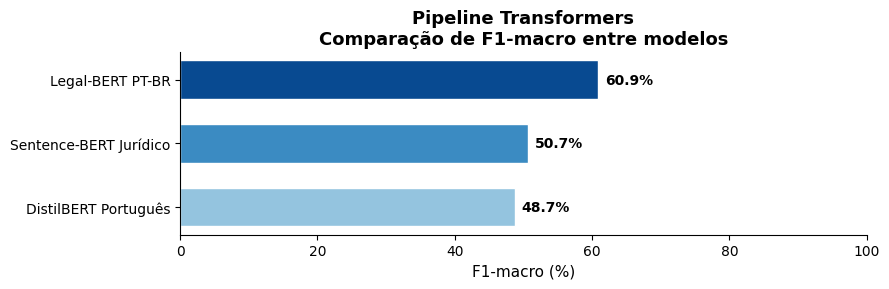

In [15]:
# ── Gráfico 1: F1-macro comparativo (barras horizontais) ────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, max(3, 0.6*len(df_resultados))))
modelos_ord = df_resultados.index.tolist()
valores     = (df_resultados['f1_macro'] * 100).tolist()

cores = plt.cm.Blues(np.linspace(0.9, 0.4, len(modelos_ord)))
bars = ax.barh(modelos_ord, valores, color=cores, edgecolor='white', height=0.6)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('F1-macro (%)', fontsize=11)
ax.set_title('Pipeline Transformers\nComparação de F1-macro entre modelos', fontsize=13, fontweight='bold')

for bar, val in zip(bars, valores):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold')

ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('f1_macro_transformers.png', dpi=150, bbox_inches='tight')
plt.show()

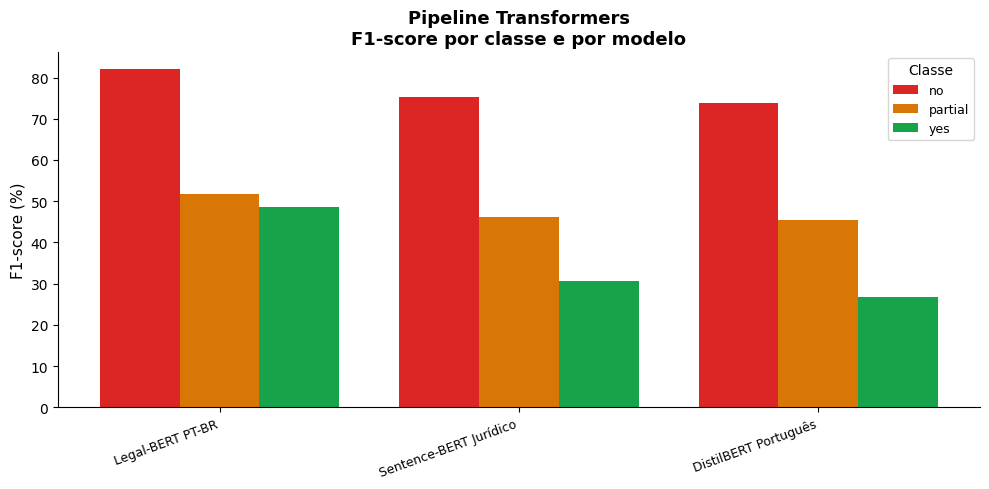

In [16]:
# ── Gráfico 2: F1 por classe (barras agrupadas) ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

n_modelos = len(modelos_ord)
n_classes = len(labels)
largura   = 0.8 / n_classes
x = np.arange(n_modelos)

cores_classe = {'yes': '#16A34A', 'partial': '#D97706', 'no': '#DC2626'}

for i, classe in enumerate(labels):
    valores_classe = [df_resultados.loc[m, f'f1_{classe}'] * 100 for m in modelos_ord]
    ax.bar(x + i*largura, valores_classe, largura,
           label=classe, color=cores_classe.get(classe, '#888888'))

ax.set_xticks(x + largura*(n_classes-1)/2)
ax.set_xticklabels(modelos_ord, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('F1-score (%)', fontsize=11)
ax.set_title('Pipeline Transformers\nF1-score por classe e por modelo', fontsize=13, fontweight='bold')
ax.legend(title='Classe', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('f1_por_classe_transformers.png', dpi=150, bbox_inches='tight')
plt.show()

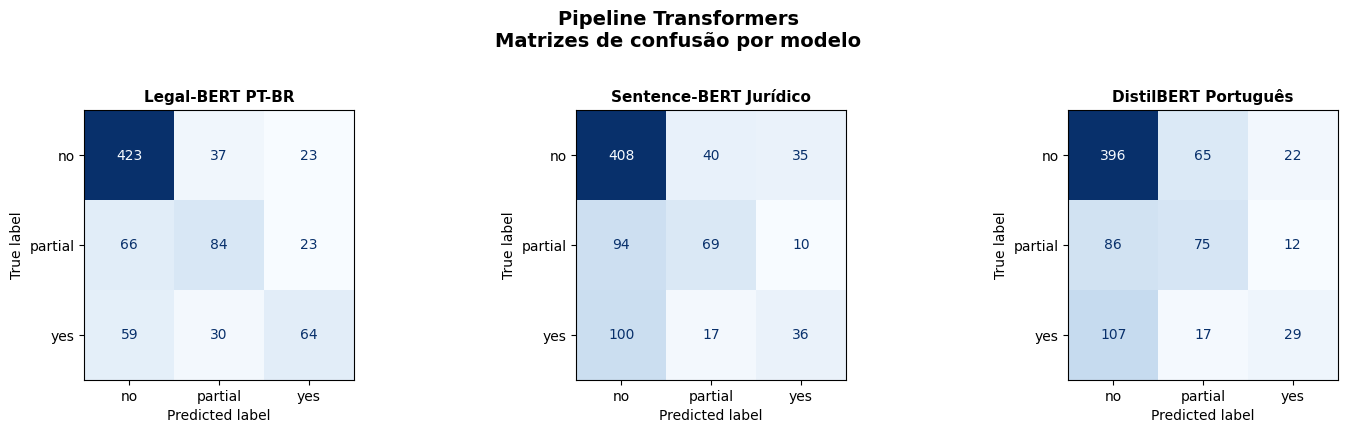

In [17]:
# ── Gráfico 3: Matrizes de confusão — grid com todos os modelos ─────────────
from sklearn.metrics import ConfusionMatrixDisplay

n = len(modelos_ord)
n_cols = min(3, n)
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4.2*n_rows))
axes = np.array(axes).reshape(-1) if n > 1 else [axes]

for i, nome in enumerate(modelos_ord):
    y_pred_modelo = preds_por_modelo[nome]
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_modelo,
        display_labels=labels, cmap='Blues',
        ax=axes[i], colorbar=False
    )
    axes[i].set_title(nome, fontsize=11, fontweight='bold')

for j in range(n, len(axes)):
    axes[j].axis('off')

plt.suptitle('Pipeline Transformers\nMatrizes de confusão por modelo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('matrizes_confusao_transformers.png', dpi=150, bbox_inches='tight')
plt.show()

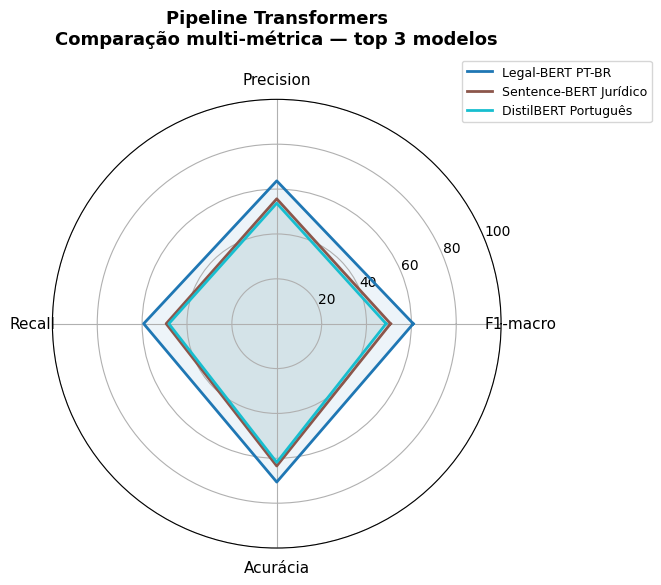

In [18]:
# ── Gráfico 4: Radar comparando 4 métricas-chave (top modelos) ──────────────
top_n = min(4, len(modelos_ord))
top_modelos = modelos_ord[:top_n]

metricas_radar = ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy']
labels_radar   = ['F1-macro', 'Precision', 'Recall', 'Acurácia']

angles = np.linspace(0, 2*np.pi, len(metricas_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
cores_radar = plt.cm.tab10(np.linspace(0, 1, top_n))

for idx, nome in enumerate(top_modelos):
    valores_radar = [df_resultados.loc[nome, m] * 100 for m in metricas_radar]
    valores_radar += valores_radar[:1]
    ax.plot(angles, valores_radar, linewidth=2, label=nome, color=cores_radar[idx])
    ax.fill(angles, valores_radar, alpha=0.08, color=cores_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('Pipeline Transformers\nComparação multi-métrica — top {} modelos'.format(top_n),
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('radar_transformers.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── Salvar resultados para comparação cruzada entre notebooks ────────────────
df_resultados.to_csv('results_transformers.csv', index=True, index_label='modelo')
print(f'Resultados salvos em: results_transformers.csv')
print(f'\nMelhor modelo deste notebook: {modelos_ord[0]}  (F1-macro = {valores[0]:.1f}%)')

Resultados salvos em: results_transformers.csv

Melhor modelo deste notebook: Legal-BERT PT-BR  (F1-macro = 60.9%)


## 13. Comparação cruzada — TF-IDF vs. Transformers
> Combina os resultados deste notebook com os do notebook TF-IDF, se ambos os arquivos CSV estiverem disponíveis no mesmo diretório.

In [1]:
import os

if os.path.exists('results_tfidf.csv'):
    df_tfidf_ext = pd.read_csv('results_tfidf.csv', index_col='modelo')
    df_transformers_ext = df_resultados.copy()

    df_tfidf_ext['vetorizacao']        = 'TF-IDF'
    df_transformers_ext['vetorizacao'] = 'Transformers'

    df_geral = pd.concat([df_tfidf_ext, df_transformers_ext])
    df_geral = df_geral.sort_values('f1_macro', ascending=False)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.55*len(df_geral))))
    cores_geral = ['#1B5A8A' if v == 'TF-IDF' else '#B45309' for v in df_geral['vetorizacao']]
    valores_geral = (df_geral['f1_macro'] * 100).tolist()

    bars = ax.barh(df_geral.index, valores_geral, color=cores_geral, edgecolor='white')
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel('F1-macro (%)')
    ax.set_title('Comparação Geral — TF-IDF vs. Transformers\nTodos os modelos testados neste projeto',
                 fontsize=13, fontweight='bold')

    for bar, val in zip(bars, valores_geral):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
                va='center', fontsize=9, fontweight='bold')

    from matplotlib.patches import Patch
    legenda = [Patch(facecolor='#1B5A8A', label='TF-IDF'),
               Patch(facecolor='#B45309', label='Transformers')]
    ax.legend(handles=legenda, loc='lower right')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('comparacao_geral_tfidf_vs_transformers.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n── RANKING GERAL (todos os modelos) ──')
    df_exibir = df_geral[['f1_macro', 'accuracy', 'vetorizacao']].copy()
    df_exibir[['f1_macro', 'accuracy']] = (df_exibir[['f1_macro', 'accuracy']] * 100).round(2)
    display(df_exibir)
else:
    print('Arquivo results_tfidf.csv não encontrado neste diretório.')
    print('Execute primeiro o notebook tfidf_pipeline_court_decisions.ipynb')
    print('e copie o results_tfidf.csv gerado para a mesma pasta deste notebook.')

NameError: name 'pd' is not defined

## 14. Conclusão

Este notebook isolou o efeito de **representações contextuais via Transformers**, com quatro abordagens distintas: fine-tuning completo (DistilBERT, Legal-BERT, BERTimbau) e embeddings congelados com classificador linear (Sentence-BERT).

A pergunta de pesquisa central — *Legal-BERT PT-BR supera o BERTimbau genérico do artigo original?* — pode ser respondida diretamente na seção 9 vs. seção 11 deste notebook.

A comparação da seção 13 mostra o panorama completo: TF-IDF vs. Transformers, todos os modelos testados em ambos os arquivos, no mesmo conjunto de teste.